In [1]:
import numpy as np 
import pandas as pd 
import matplotlib as mpl 
import matplotlib.pyplot as plt 
import seaborn as sns 
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown, HTML


In [2]:
import os
path = os.path.join("..", "data", "raw", "house_sales.csv")
houses = pd.read_csv(path)
houses

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2.0,1.00,770.0,10000.0,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3.0,2.50,1530.0,1131.0,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4.0,2.50,2310.0,5813.0,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2.0,0.75,1020.0,1350.0,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3.0,2.50,1600.0,2388.0,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [3]:
houses.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       20479 non-null  float64
 4   bathrooms      20545 non-null  float64
 5   sqft_living    20503 non-null  float64
 6   sqft_lot       20569 non-null  float64
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [4]:
houses.isnull().sum()

id                  0
date                0
price               0
bedrooms         1134
bathrooms        1068
sqft_living      1110
sqft_lot         1044
floors              0
waterfront          0
view                0
condition           0
grade               0
sqft_above          0
sqft_basement       0
yr_built            0
yr_renovated        0
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
dtype: int64

In [5]:
#All null values are numeric 
#Replace null values with median values
df_clean = houses.copy()

df_clean["bedrooms"] = df_clean["bedrooms"].fillna(df_clean["bedrooms"].median())
df_clean["bathrooms"] = df_clean["bathrooms"].fillna(df_clean["bathrooms"].median())
df_clean["sqft_living"] = df_clean["sqft_living"].fillna(df_clean["sqft_living"].median())
df_clean["sqft_lot"] = df_clean["sqft_lot"].fillna(df_clean["sqft_lot"].median())

df_clean.isnull().sum()


id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [6]:
#Convert date column from string to datetime

df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21613 non-null  int64         
 1   date           21613 non-null  datetime64[us]
 2   price          21613 non-null  float64       
 3   bedrooms       21613 non-null  float64       
 4   bathrooms      21613 non-null  float64       
 5   sqft_living    21613 non-null  float64       
 6   sqft_lot       21613 non-null  float64       
 7   floors         21613 non-null  float64       
 8   waterfront     21613 non-null  int64         
 9   view           21613 non-null  int64         
 10  condition      21613 non-null  int64         
 11  grade          21613 non-null  int64         
 12  sqft_above     21613 non-null  int64         
 13  sqft_basement  21613 non-null  int64         
 14  yr_built       21613 non-null  int64         
 15  yr_renovated   21613 non-null 

In [7]:
#Save the clean data to a new csv file in the processed data folder 

os.makedirs("../data/processed", exist_ok=True)
df_clean.to_csv("../data/processed/clean_data.csv", index=False)

In [8]:
#Import clean data with unique values from Cassie

df_unique = pd.read_csv("../data/processed/unique_clean_df.csv") 
df_unique.info()

<class 'pandas.DataFrame'>
RangeIndex: 21436 entries, 0 to 21435
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21436 non-null  int64  
 1   date           21436 non-null  str    
 2   price          21436 non-null  float64
 3   bedrooms       21436 non-null  float64
 4   bathrooms      21436 non-null  float64
 5   sqft_living    21436 non-null  float64
 6   sqft_lot       21436 non-null  float64
 7   floors         21436 non-null  float64
 8   waterfront     21436 non-null  int64  
 9   view           21436 non-null  int64  
 10  condition      21436 non-null  int64  
 11  grade          21436 non-null  int64  
 12  sqft_above     21436 non-null  int64  
 13  sqft_basement  21436 non-null  int64  
 14  yr_built       21436 non-null  int64  
 15  yr_renovated   21436 non-null  int64  
 16  zipcode        21436 non-null  int64  
 17  lat            21436 non-null  float64
 18  long           21

In [9]:
#Import cleaned and wrangled data from Meeki

df_unique = pd.read_csv("../data/processed/final_clean_data.csv") 
df_unique.info()

<class 'pandas.DataFrame'>
RangeIndex: 21436 entries, 0 to 21435
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                21436 non-null  int64  
 1   date              21436 non-null  str    
 2   price             21436 non-null  float64
 3   bedrooms          21436 non-null  float64
 4   bathrooms         21436 non-null  float64
 5   sqft_living       21436 non-null  float64
 6   sqft_lot          21436 non-null  float64
 7   floors            21436 non-null  float64
 8   waterfront        21436 non-null  int64  
 9   view              21436 non-null  int64  
 10  condition         21436 non-null  int64  
 11  grade             21436 non-null  int64  
 12  sqft_above        21436 non-null  int64  
 13  sqft_basement     21436 non-null  int64  
 14  yr_renovated      21436 non-null  int64  
 15  zipcode           21436 non-null  int64  
 16  lat               21436 non-null  float64
 17  long

In [10]:
#Print measures of centrality of data columns of interest

centrality = df_unique[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'condition', 'grade', 'house_age', 'yr_renovated']].agg(['mean', 'median'])
print(centrality)

               price  bedrooms  bathrooms  sqft_living      sqft_lot  \
mean    540529.28718  3.353797   2.122749  2075.338403  14841.319043   
median  450000.00000  3.000000   2.250000  1920.000000   7620.000000   

        condition     grade  house_age  yr_renovated  
mean     3.410384  7.661737  43.220517       84.7298  
median   3.000000  7.000000  39.000000        0.0000  


In [11]:
#Print modes of data columns of interest

df_unique[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'condition', 'grade', 'house_age', 'yr_renovated']].mode()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,condition,grade,house_age,yr_renovated
0,350000.0,3.0,2.5,1920.0,7620.0,3,7,9,0


In [12]:
#Print measures of distribution of data columns of interest

distribution = df_unique[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'condition', 'grade', 'house_age', 'yr_renovated']].describe()
display(distribution.style.format("{:,.2f}").background_gradient(cmap='Blues').set_caption("Distribution Summary Statistics"))

,price,bedrooms,bathrooms,sqft_living,sqft_lot,condition,grade,house_age,yr_renovated
count,"21,436.00","21,436.00","21,436.00","21,436.00","21,436.00","21,436.00","21,436.00","21,436.00","21,436.00"
mean,"540,529.29",3.35,2.12,"2,075.34","14,841.32",3.41,7.66,43.22,84.73
std,"367,689.30",0.91,0.75,892.82,"40,617.63",0.65,1.17,29.39,402.43
min,"75,000.00",0.00,0.00,290.00,520.00,1.00,1.00,-1.00,0.00
25%,"322,150.00",3.00,1.75,"1,450.00","5,130.00",3.00,7.00,17.00,0.00
50%,"450,000.00",3.00,2.25,"1,920.00","7,620.00",3.00,7.00,39.00,0.00
75%,"645,000.00",4.00,2.50,"2,510.00","10,414.50",4.00,8.00,63.00,0.00
max,"7,700,000.00",33.00,8.00,"12,050.00","1,651,359.00",5.00,13.00,115.00,"2,015.00"


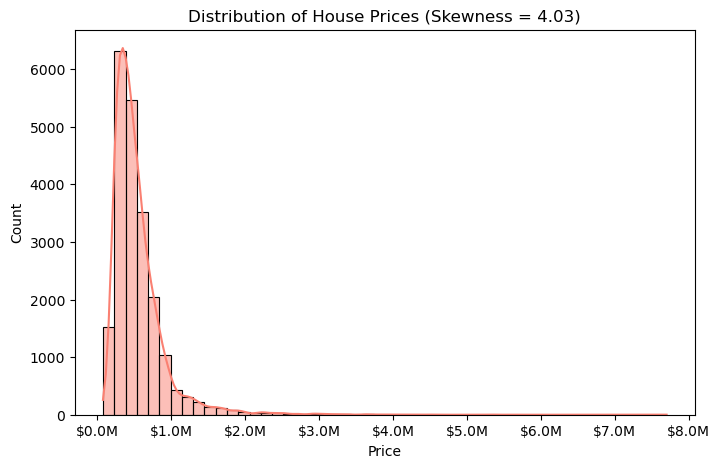

In [13]:
#Create visualizations of the distribution of price

plt.figure(figsize=(8,5))
sns.histplot(df_unique['price'], bins=50, kde=True, color='salmon')

# format x-axis as currency
formatter = FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
plt.gca().xaxis.set_major_formatter(formatter)

# calculate skewness
skewness = df_unique['price'].skew()

plt.title(f"Distribution of House Prices (Skewness = {skewness:.2f})")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

display(HTML(f"""
<h3>Price Distribution Summary</h3>
<ul>
  <li>Mean Price: ${df_unique['price'].mean():,.0f}</li>
  <li>Median Price: ${df_unique['price'].median():,.0f}</li>
  <li>Skewness: {skewness:.2f}</li>
</ul>

<p>
The distribution of housing prices exhibits positive skewness, indicating that while most homes cluster around lower to mid-range values, a small number of high-priced properties extend the right tail.
</p>
"""))

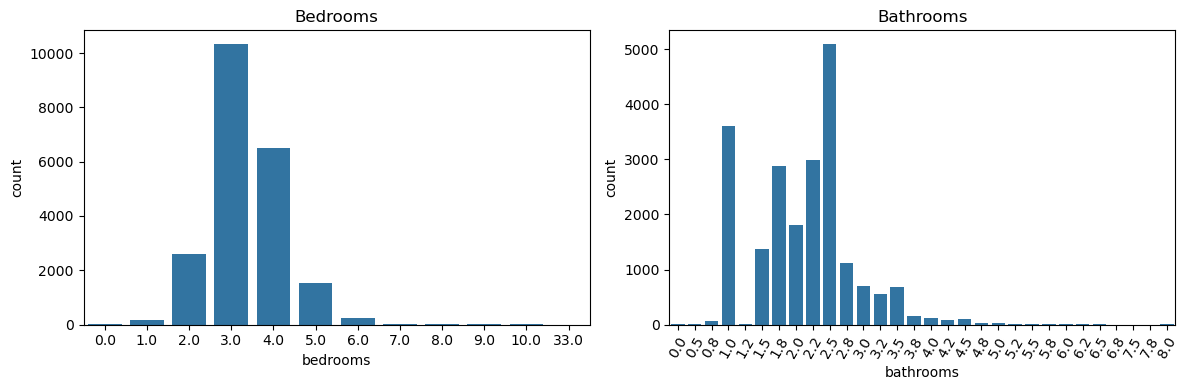

In [14]:
#Create visualizations of the distribution of bedroom/bathroom counts

fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.countplot(x='bedrooms', data=df_unique, ax=axes[0])
axes[0].set_title("Bedrooms")

sns.countplot(x=df_unique['bathrooms'].round(1), ax=axes[1])
axes[1].set_title("Bathrooms")
axes[1].tick_params(axis='x', rotation=60)


plt.tight_layout()
plt.show()

display(HTML(f"""

<h3>
The distribution of bedrooms and bathrooms shows that most homes cluster around 3–4 bedrooms and 2–2.5 bathrooms. Extreme values are rare, indicating that the dataset primarily represents moderately sized residential properties.
</h3>
"""))

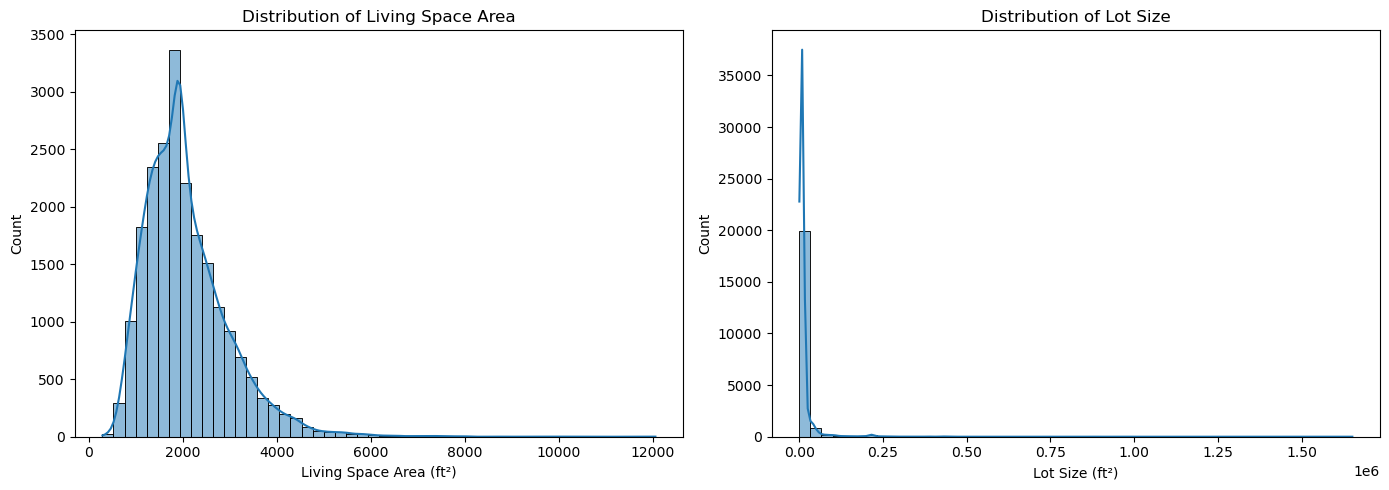

In [38]:
#Create visualization showing distribution of square footage

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# sqft_living
sns.histplot(df_unique['sqft_living'], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Living Space Area")
axes[0].set_xlabel("Living Space Area (ft²)")
axes[0].set_ylabel("Count")

# sqft_lot
sns.histplot(df_unique['sqft_lot'], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Lot Size")
axes[1].set_xlabel("Lot Size (ft²)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

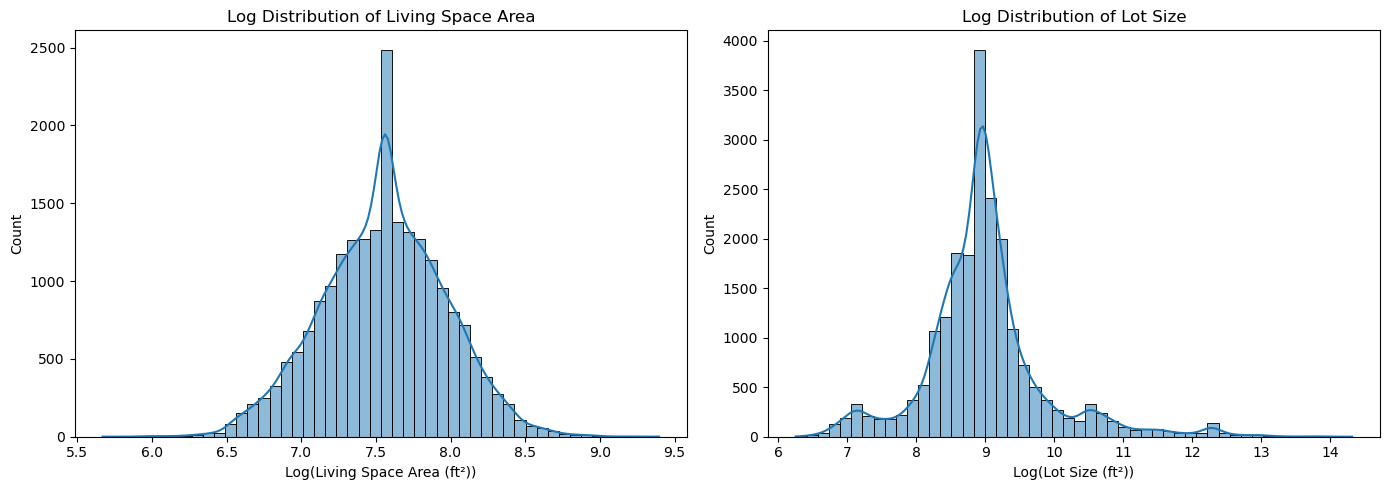

In [40]:
# Create Log distributions to improve readability/interpretability

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(np.log(df_unique['sqft_living']), bins=50, kde=True, ax=axes[0])
axes[0].set_title("Log Distribution of Living Space Area")
axes[0].set_xlabel("Log(Living Space Area (ft²))")

sns.histplot(np.log(df_unique['sqft_lot']), bins=50, kde=True, ax=axes[1])
axes[1].set_title("Log Distribution of Lot Size")
axes[1].set_xlabel("Log(Lot Size (ft²))")

plt.tight_layout()
plt.show()

In [17]:
display(HTML(f"""

<h3>
The distributions of both living space and lot size are positively skewed, with lot size exhibiting a more extreme right tail. This indicates that while most homes have moderate square footage, a small number of properties with very large lots significantly influence the distribution.
</h3>
"""))

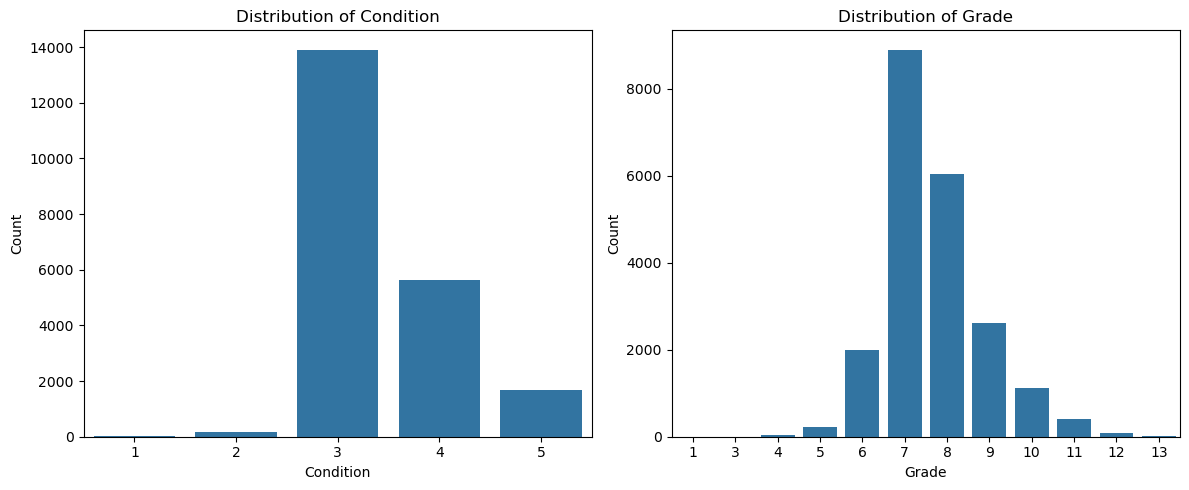

In [18]:
# Create Visualizations to show the distribution of condition and construction grade

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Condition
sns.countplot(
    x='condition',
    data=df_unique,
    order=sorted(df_unique['condition'].unique()),
    ax=axes[0]
)
axes[0].set_title("Distribution of Condition")
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Count")

# Grade
sns.countplot(
    x='grade',
    data=df_unique,
    order=sorted(df_unique['grade'].unique()),
    ax=axes[1]
)
axes[1].set_title("Distribution of Grade")
axes[1].set_xlabel("Grade")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

display(HTML(f"""

<h3>
The distribution of condition is heavily concentrated around average values, with most properties rated as condition 3, indicating typical maintenance levels. Similarly, grade values cluster between 6 and 8, suggesting that the majority of homes are of mid-range construction quality, with relatively few high-end or low-quality properties.
</h3>
"""))

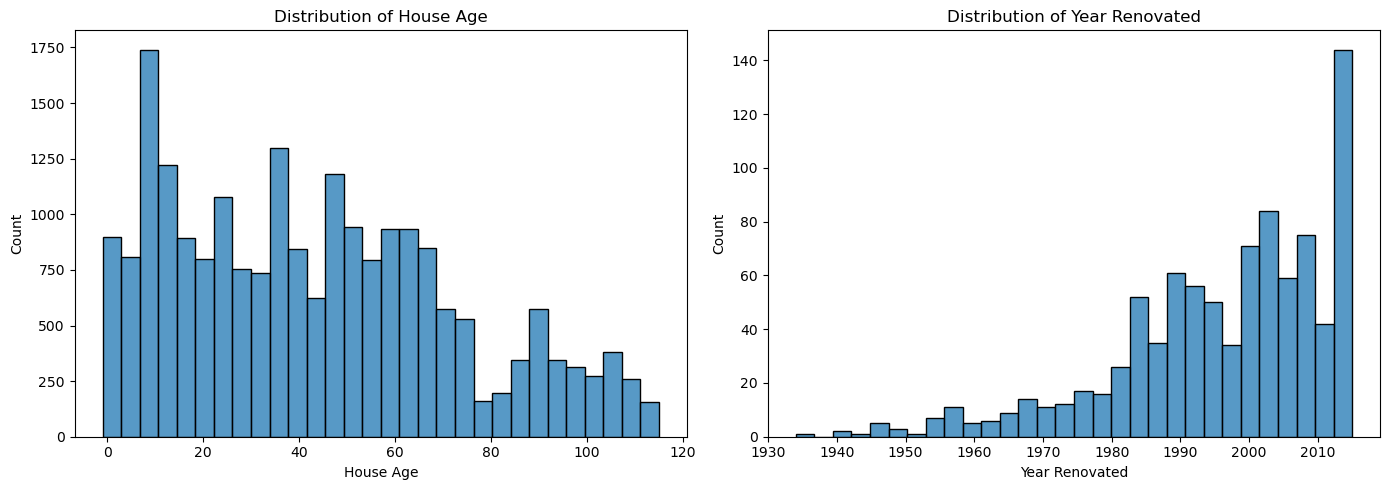

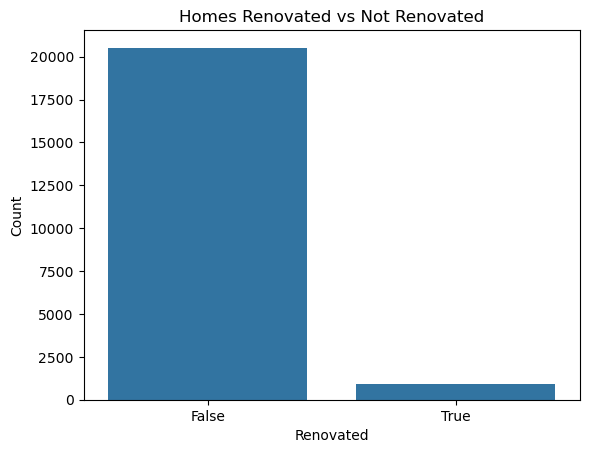

In [19]:
# Create visualizations showing the distribution of year built and year renovated

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Year Built
sns.histplot(df_unique['house_age'], bins=30, kde=False, ax=axes[0])
axes[0].set_title("Distribution of House Age")
axes[0].set_xlabel("House Age")
axes[0].set_ylabel("Count")

# Year Renovated (excluding zeros)
sns.histplot(df_unique[df_unique['yr_renovated'] > 0]['yr_renovated'], bins=30, kde=False, ax=axes[1])
axes[1].set_title("Distribution of Year Renovated")
axes[1].set_xlabel("Year Renovated")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

df_unique['renovated'] = df_unique['yr_renovated'] > 0

sns.countplot(x='renovated', data=df_unique)
plt.title("Homes Renovated vs Not Renovated")
plt.xlabel("Renovated")
plt.ylabel("Count")
plt.show()

display(HTML(f"""

<h3>
The distribution of year built shows that most homes were constructed in the latter half of the 20th century, with fewer older properties. In contrast, the year renovated variable contains many missing values (indicating no renovation), and among renovated homes, updates are concentrated in more recent years, suggesting that renovations are relatively infrequent but tend to occur in modern periods.
"""))

In [20]:
# Create a correlation matrix to begin analyzing variable correlations
corr = df_unique.corr(numeric_only=True)
corr

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_basement,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,house_age,sqft_living_norm,renovated
id,1.000000,-0.018514,0.004094,0.001223,-0.012492,-0.130999,0.018057,-0.002746,0.010929,-0.024279,...,-0.005795,-0.017178,-0.007948,-0.002859,0.019466,-0.004084,-0.139670,-0.020770,-0.012492,-0.017212
price,-0.018514,1.000000,0.303175,0.515662,0.681615,0.085755,0.256278,0.266961,0.396933,0.035089,...,0.323552,0.127002,-0.052171,0.306057,0.020571,0.584688,0.082038,-0.052891,0.681615,0.126666
bedrooms,0.004094,0.303175,1.000000,0.487939,0.550048,0.027225,0.172015,-0.005123,0.079824,0.027760,...,0.291489,0.018883,-0.150522,-0.010213,0.126862,0.382631,0.023959,-0.150096,0.550048,0.018597
bathrooms,0.001223,0.515662,0.487939,1.000000,0.714171,0.082546,0.487177,0.067128,0.180304,-0.126004,...,0.276681,0.048922,-0.199681,0.025383,0.217452,0.554130,0.085954,-0.494844,0.714171,0.048455
sqft_living,-0.012492,0.681615,0.550048,0.714171,1.000000,0.158742,0.344357,0.105288,0.276142,-0.059712,...,0.420277,0.055608,-0.193103,0.048510,0.232086,0.736938,0.174503,-0.309952,1.000000,0.055338
sqft_lot,-0.130999,0.085755,0.027225,0.082546,0.158742,1.000000,-0.006467,0.020754,0.073859,-0.009094,...,0.015180,0.008588,-0.127595,-0.085584,0.223781,0.141119,0.717168,-0.049806,0.158742,0.008684
floors,0.018057,0.256278,0.172015,0.487177,0.344357,-0.006467,1.000000,0.023473,0.028211,-0.266543,...,-0.246066,0.005626,-0.058108,0.049279,0.124285,0.278854,-0.011917,-0.489357,0.344357,0.005549
waterfront,-0.002746,0.266961,-0.005123,0.067128,0.105288,0.020754,0.023473,1.000000,0.403025,0.016607,...,0.080838,0.093025,0.030558,-0.014395,-0.042188,0.086558,0.030694,0.026482,0.105288,0.093439
view,0.010929,0.396933,0.079824,0.180304,0.276142,0.073859,0.028211,0.403025,1.000000,0.045051,...,0.276482,0.103633,0.087096,0.005671,-0.079720,0.279077,0.072867,0.055201,0.276142,0.103777
condition,-0.024279,0.035089,0.027760,-0.126004,-0.059712,-0.009094,-0.266543,0.016607,0.045051,1.000000,...,0.174463,-0.061136,0.004509,-0.015402,-0.107780,-0.095002,-0.003731,0.364238,-0.059712,-0.060655


In [21]:
display(HTML(f"""
<h3>
A correlation matrix was used to evaluate relationships between variables. Strong correlations are observed between square footage of living space and square footage "above," however this indicates multicollinearity, and shows correlation rather than causation. Next we will look at just the correlations with price.
"""))

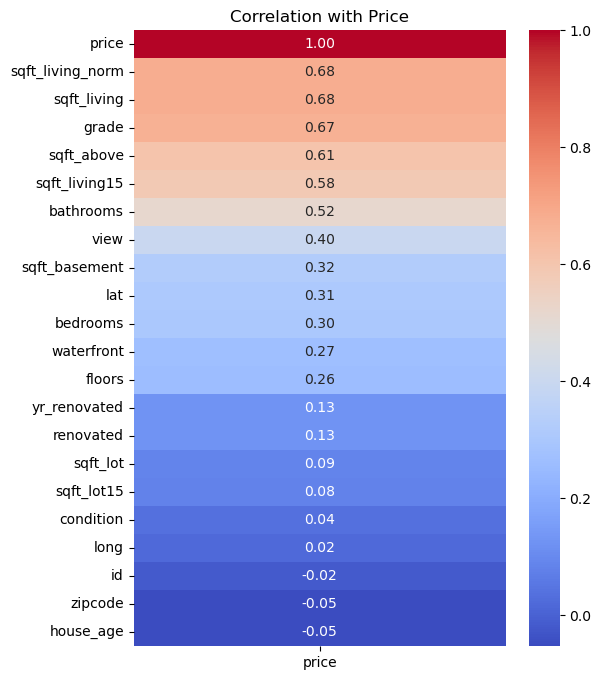

In [22]:
# View only variable correlations with price

price_corr = corr[['price']].sort_values(by='price', ascending=False)

plt.figure(figsize=(6,8))
sns.heatmap(price_corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation with Price")
plt.show()

display(HTML(f"""
<h3>
Price is most strongly correlated with living space square footage, construction grade, and number of bathrooms. The linear relationships between price and these three variables will be explored further.
"""))

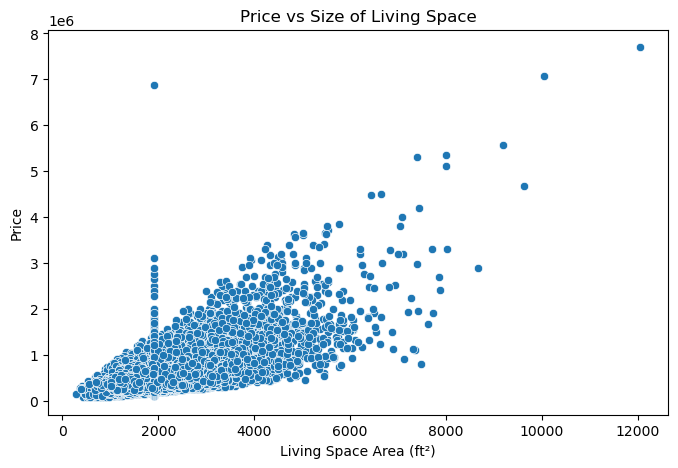

In [41]:
# Analyze relationship between price and living space

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='sqft_living',
    y='price',
    data=df_unique,
)

plt.title("Price vs Size of Living Space")
plt.xlabel("Living Space Area (ft²)")
plt.ylabel("Price")

plt.show()



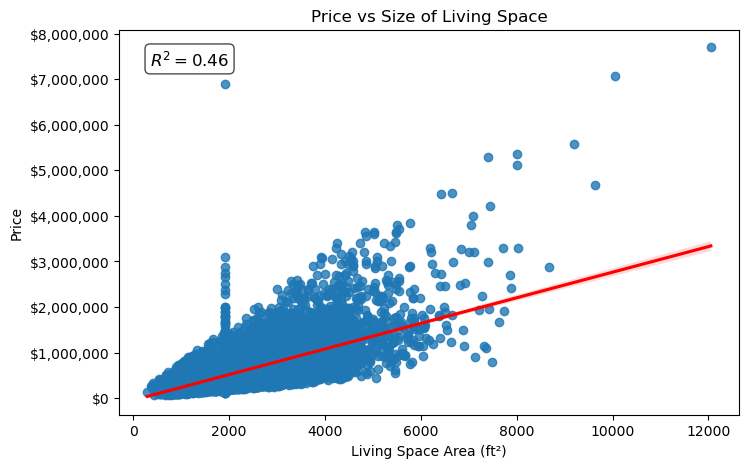

In [42]:
X = df_unique[['sqft_living']]
y = df_unique['price']

r = np.corrcoef(df_unique['sqft_living'], df_unique['price'])[0,1]
r2 = r**2

plt.figure(figsize=(8,5))

sns.regplot(
    x='sqft_living',
    y='price',
    data=df_unique,
    line_kws={'color':'red'})

# Format y-axis as currency
formatter = FuncFormatter(lambda x, _: f'${int(x):,}')
plt.gca().yaxis.set_major_formatter(formatter)

# Add R² annotation on plot
plt.text(
    0.05, 0.95,                     # position (relative to plot)
    f'$R^2 = {r2:.2f}$',
    transform=plt.gca().transAxes,  # makes position relative
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
)

plt.title("Price vs Size of Living Space")
plt.xlabel("Living Space Area (ft²)")
plt.ylabel("Price")

plt.show()

display(HTML(f"""
<h3>
There is a moderate positive relationship between size of living space. The R² value of 0.46 indicates that approximately 46% of the variation in housing prices can be explained by differences in living space.
"""))

m1, b1 = np.polyfit(df_unique['sqft_living'], df_unique['price'], 1)


display(HTML(f"""
<h3>
Price = {m1:.2f} * sqft_living + {b1:.2f}
"""))


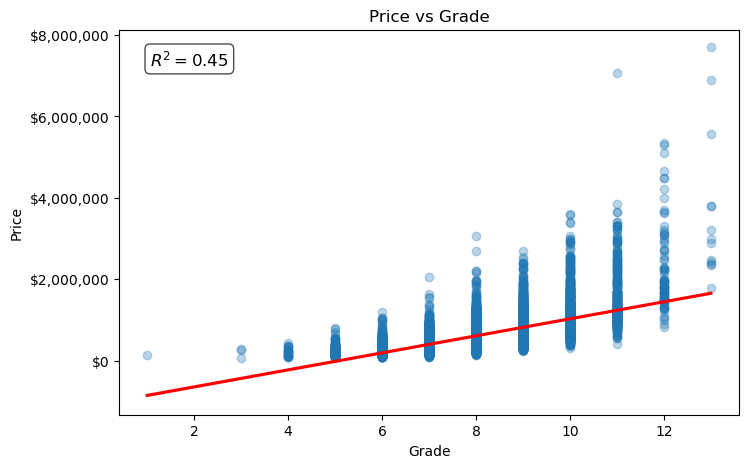

In [25]:
X = df_unique[['grade']]
y = df_unique['price']

# Calculate R²
r = np.corrcoef(df_unique['grade'], df_unique['price'])[0,1]
r2 = r**2

plt.figure(figsize=(8,5))

sns.regplot(
    x='grade',
    y='price',
    data=df_unique,
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

# Format y-axis as currency
formatter = FuncFormatter(lambda x, _: f'${int(x):,}')
plt.gca().yaxis.set_major_formatter(formatter)

# Add R² annotation
plt.text(
    0.05, 0.95,
    f'$R^2 = {r2:.2f}$',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
)

plt.title("Price vs Grade")
plt.xlabel("Grade")
plt.ylabel("Price")

plt.show()

# Interpretation
display(HTML(f"""
<h3>
There is a positive relationship between construction quality (grade) and housing price. The R² value of {r2:.2f} indicates that approximately {r2*100:.0f}% of the variation in housing prices can be explained by differences in grade.
Since the construction grade data is categorical, a boxplot may present better.
</h3>
"""))

m2, b2 = np.polyfit(df_unique['grade'], df_unique['price'], 1)

display(HTML(f"""
<h3>
Price = {m2:.2f} * grade + {b2:.2f}
</h3>
"""))

<Axes: xlabel='grade', ylabel='price'>

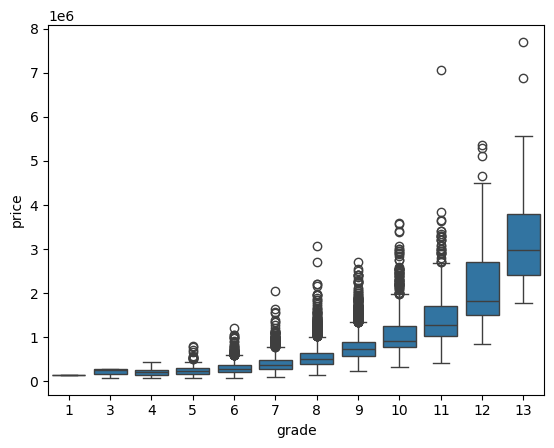

In [44]:
sns.boxplot(x='grade', y='price', data=df_unique)

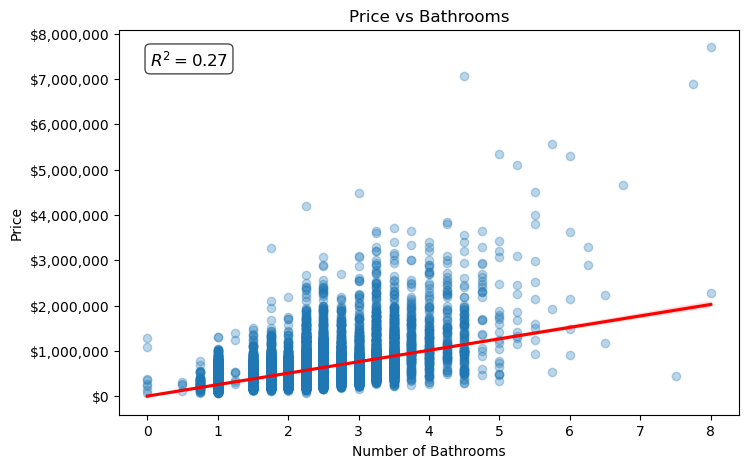

In [27]:
X = df_unique[['bathrooms']]
y = df_unique['price']

# Calculate R²
r = np.corrcoef(df_unique['bathrooms'], df_unique['price'])[0,1]
r2 = r**2

plt.figure(figsize=(8,5))

sns.regplot(
    x='bathrooms',
    y='price',
    data=df_unique,
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

# Format y-axis as currency
formatter = FuncFormatter(lambda x, _: f'${int(x):,}')
plt.gca().yaxis.set_major_formatter(formatter)

# Add R² annotation
plt.text(
    0.05, 0.95,
    f'$R^2 = {r2:.2f}$',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
)

plt.title("Price vs Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price")

plt.show()

# Interpretation
display(HTML(f"""
<h3>
There is a positive relationship between the number of bathrooms and housing price. The R² value of {r2:.2f} indicates that approximately {r2*100:.0f}% of the variation in housing prices can be explained by differences in the number of bathrooms.
</h3>
"""))

m3, b3 = np.polyfit(df_unique['bathrooms'], df_unique['price'], 1)

display(HTML(f"""
<h3>
Price = {m3:.2f} * bathrooms + {b3:.2f}
</h3>
"""))

In [28]:
# Multiple Regression Analysis

X = df_unique[['sqft_living', 'grade', 'bathrooms']].values
y = df_unique['price'].values

X = np.column_stack((np.ones(len(X)), X))

beta = np.linalg.lstsq(X, y, rcond=None)[0]

b0 = beta[0]  # intercept
b1 = beta[1]  # sqft_living
b2 = beta[2]  # grade
b3 = beta[3]  # bathrooms

display(HTML(f"""
<h3>Multiple Regression Model Equation:</h3>
<p><b>
Price = {b1:.2f} × sqft_living + {b2:.2f} × grade + {b3:.2f} × bathrooms + {b0:.2f}
</b></p>
"""))

In [29]:
y_pred = X @ beta

ss_total = np.sum((y - y.mean())**2)
ss_res = np.sum((y - y_pred)**2)

r2 = 1 - (ss_res / ss_total)

display(HTML(f"""
<h3>Multiple Regression Model R squared:</h3>
<p><b>
R²: {r2:.2f}
</b></p>
"""))

In [30]:
display(HTML(f"""
<h3>A multiple linear regression model was developed using square footage, grade, and number of bathrooms as predictors. The model achieved an R² of 0.52, indicating that these variables jointly explain a substantial portion of the variation in housing prices.</h3>

"""))

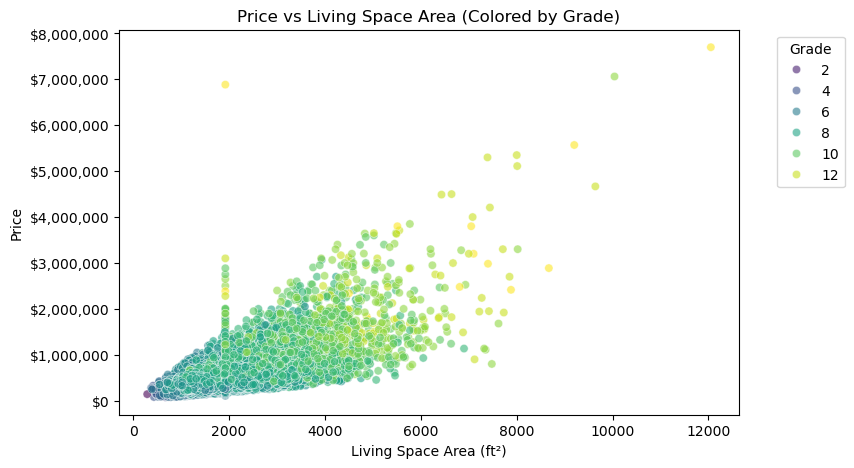

In [46]:
#Attempt to visualize affect of square footage and construction grade on price in one graph

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='sqft_living',
    y='price',
    hue='grade',          # color by grade
    data=df_unique,
    alpha=0.6,
    palette='viridis'
)

# Format y-axis as currency
formatter = FuncFormatter(lambda x, _: f'${int(x):,}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Price vs Living Space Area (Colored by Grade)")
plt.xlabel("Living Space Area (ft²)")
plt.ylabel("Price")

plt.legend(title="Grade", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [32]:
display(HTML(f"""
<h3>
The above scatter plot is an attempt to visualize the relationship between price, square footage, and construction quality in one graph. The scatter plot colored by grade reveals that homes with higher construction quality tend to command higher prices, even at similar levels of square footage.
</h3>
"""))

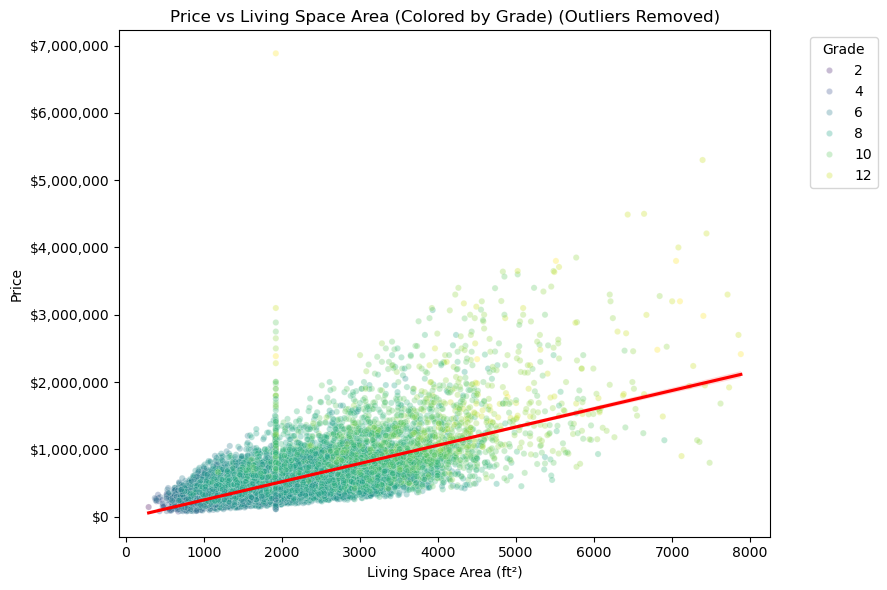

In [48]:
plt.figure(figsize=(9,6))

df_plot = df_unique[df_unique['sqft_living'] < 8000]

sns.scatterplot(
    x='sqft_living',
    y='price',
    hue='grade',
    data=df_plot,
    alpha=0.3,
    s=20,
    palette='viridis'
)

sns.regplot(
    x='sqft_living',
    y='price',
    data=df_plot,
    scatter=False,
    line_kws={'color':'red'}
)

formatter = FuncFormatter(lambda x, _: f'${int(x):,}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Price vs Living Space Area (Colored by Grade) (Outliers Removed)")
plt.xlabel("Living Space Area (ft²)")
plt.ylabel("Price")

plt.legend(title="Grade", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()